# 12. Оценка опционов методом Монте-Карло

**Статус:** завершено

Метод Монте-Карло оценивает цену опциона как дисконтированное математическое ожидание выплаты под риск-нейтральной мерой. Мы сравним оценки с Black–Scholes, построим доверительные интервалы, посмотрим сходимость и variance reduction.

## Риск-нейтральная идея

Для европейского payoff $H(S_T)$ цена равна

$$V_0=e^{-rT}\mathbb E^Q[H(S_T)].$$

Под мерой $Q$ цена GBM имеет снос $r$, а не историческое $\mu$:

$$S_T=S_0\exp\left((r-\frac12\sigma^2)T+\sigma\sqrt{T}Z\right).$$

MC-оценка — это среднее независимых payoff. Стандартная ошибка убывает как $1/\sqrt n$, поэтому для увеличения точности в 10 раз нужно примерно в 100 раз больше путей.

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.monte_carlo_option_pricing import (
    calculate_arithmetic_asian_call_payoffs,
    calculate_black_scholes_call_and_put_prices,
    calculate_european_call_put_payoffs,
    calculate_up_and_out_call_payoffs,
    estimate_discounted_option_price_from_payoffs,
    plot_monte_carlo_convergence,
    simulate_risk_neutral_price_paths,
    simulate_risk_neutral_terminal_prices,
)

## 1. Европейские call и put

In [2]:
spot, strike, rate, sigma, maturity = 100.0, 100.0, 0.05, 0.20, 1.0
bs_call, bs_put = calculate_black_scholes_call_and_put_prices(spot, strike, rate, sigma, maturity)
terminal_prices = simulate_risk_neutral_terminal_prices(50000, spot, rate, sigma, maturity, random_seed=123)
call_payoffs, put_payoffs = calculate_european_call_put_payoffs(terminal_prices, strike)
call_estimate = estimate_discounted_option_price_from_payoffs(call_payoffs, rate, maturity)
put_estimate = estimate_discounted_option_price_from_payoffs(put_payoffs, rate, maturity)

pd.DataFrame({
    "Инструмент": ["Call", "Put"],
    "MC цена": [call_estimate[0], put_estimate[0]],
    "Std error": [call_estimate[1], put_estimate[1]],
    "CI low": [call_estimate[2][0], put_estimate[2][0]],
    "CI high": [call_estimate[2][1], put_estimate[2][1]],
    "Black-Scholes": [bs_call, bs_put],
})

,Инструмент,MC цена,Std error,CI low,CI high,Black-Scholes
0,Call,10.4837,0.0659,10.3545,10.6129,10.4506
1,Put,5.5515,0.0386,5.4758,5.6272,5.5735


MC-цена call `10.4837` попала близко к Black–Scholes `10.4506`; 95% интервал `[10.3545, 10.6129]` покрывает аналитическую цену. Put аналогично: `5.5515` против `5.5735`.

Это хороший sanity check: если простой европейский опцион не сходится к Black–Scholes, значит ошибка либо в дисконтировании, либо в риск-нейтральном сносе, либо в payoff.

## 2. Сходимость и antithetic variates

,Метод,Цена call,Std error
0,обычный MC,10.4837,0.0659
1,antithetic,10.4533,0.0659


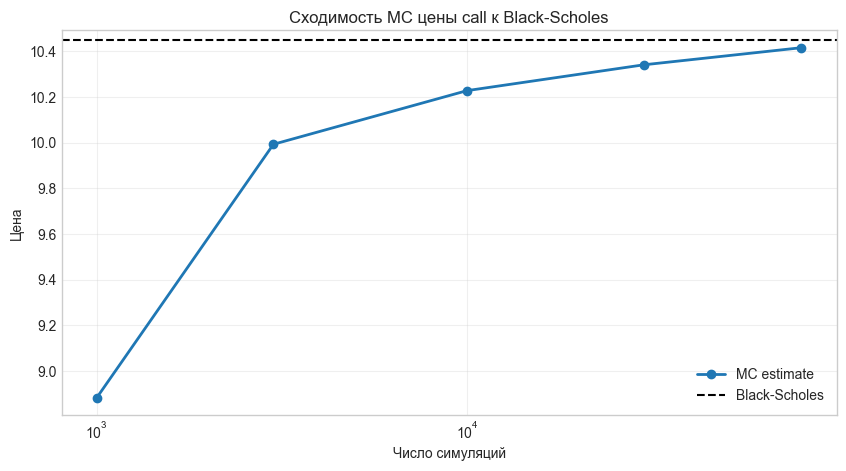

In [3]:
path_counts = np.array([1000, 3000, 10000, 30000, 80000])
estimates=[]
for count in path_counts:
    terminal = simulate_risk_neutral_terminal_prices(int(count), spot, rate, sigma, maturity, random_seed=7)
    estimates.append(estimate_discounted_option_price_from_payoffs(calculate_european_call_put_payoffs(terminal, strike)[0], rate, maturity)[0])
plot_monte_carlo_convergence(path_counts, np.array(estimates), bs_call, "Сходимость MC цены call к Black-Scholes");

antithetic_terminal = simulate_risk_neutral_terminal_prices(50000, spot, rate, sigma, maturity, random_seed=123, antithetic=True)
antithetic_call = estimate_discounted_option_price_from_payoffs(calculate_european_call_put_payoffs(antithetic_terminal, strike)[0], rate, maturity)
pd.DataFrame({"Метод": ["обычный MC", "antithetic"], "Цена call": [call_estimate[0], antithetic_call[0]], "Std error": [call_estimate[1], antithetic_call[1]]})

На графике оценка колеблется вокруг аналитической цены, а амплитуда колебаний уменьшается с ростом числа симуляций. Antithetic variates использует пары $Z$ и $-Z$: это часто снижает дисперсию для монотонных payoff, хотя выигрыш зависит от конкретного опциона и параметров.

## 3. Path-dependent опционы: Asian и barrier

In [4]:
path_time_grid, price_paths = simulate_risk_neutral_price_paths(30000, 252, spot, rate, sigma, maturity, random_seed=321)
asian_call = estimate_discounted_option_price_from_payoffs(calculate_arithmetic_asian_call_payoffs(price_paths, strike), rate, maturity)
barrier_call = estimate_discounted_option_price_from_payoffs(calculate_up_and_out_call_payoffs(price_paths, strike, barrier=130.0), rate, maturity)
pd.DataFrame({
    "Опцион": ["Arithmetic Asian call", "Up-and-out call, barrier=130"],
    "MC цена": [asian_call[0], barrier_call[0]],
    "Std error": [asian_call[1], barrier_call[1]],
    "CI low": [asian_call[2][0], barrier_call[2][0]],
    "CI high": [asian_call[2][1], barrier_call[2][1]],
})

,Опцион,MC цена,Std error,CI low,CI high
0,Arithmetic Asian call,5.8339,0.0466,5.7425,5.9253
1,"Up-and-out call, barrier=130",3.5796,0.0370,3.5071,3.6522


Asian call стоит `5.8339`, заметно дешевле vanilla call, потому что усреднение цены снижает волатильность payoff. Up-and-out call стоит `3.5796`: он может быть занулён при достижении барьера, поэтому барьерная опция дешевле обычного call.

Здесь сила MC особенно видна: для path-dependent payoff часто нет простой closed-form формулы, но симуляция остаётся прямой.

## Выводы

1. Цена опциона в MC — дисконтированное среднее payoff под риск-нейтральной мерой.
2. Стандартная ошибка убывает как $1/\sqrt n$.
3. Black–Scholes полезен как эталон для проверки европейских опционов.
4. Antithetic variates может снижать дисперсию без изменения математического ожидания.
5. MC особенно удобен для Asian, barrier и других path-dependent инструментов.